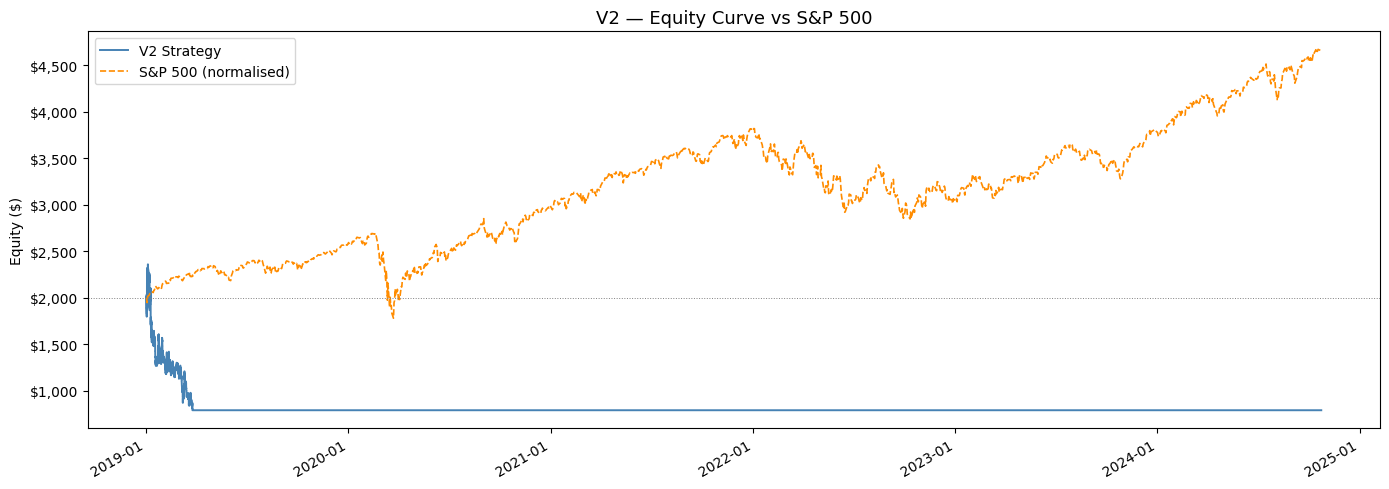

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

# ── Load iteration artifacts ──────────────────────────────────────────────────
ec   = pd.read_csv("equity_curve.csv", parse_dates=["time"])
meta = json.load(open("metadata.json"))
VERSION  = meta["version"]
START_EQ = meta["STARTING_EQUITY"]

# ── Fetch S&P 500 for same period ─────────────────────────────────────────────
import yfinance as yf
start_dt = ec["time"].dt.date.min().isoformat()
end_dt   = ec["time"].dt.date.max().isoformat()
sp_raw   = yf.download("^GSPC", start=start_dt, end=end_dt,
                        auto_adjust=True, progress=False)["Close"].squeeze()
sp_norm  = sp_raw / sp_raw.iloc[0] * START_EQ  # normalised to same start equity

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ec["time"], ec["equity"], color="steelblue", lw=1.4,
        label=f"{VERSION} Strategy")
ax.plot(sp_norm.index, sp_norm.values, color="darkorange", lw=1.2,
        linestyle="--", label="S&P 500 (normalised)")
ax.axhline(START_EQ, color="gray", lw=0.7, linestyle=":")
ax.set_title(f"{VERSION} — Equity Curve vs S&P 500", fontsize=13)
ax.set_ylabel("Equity ($)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


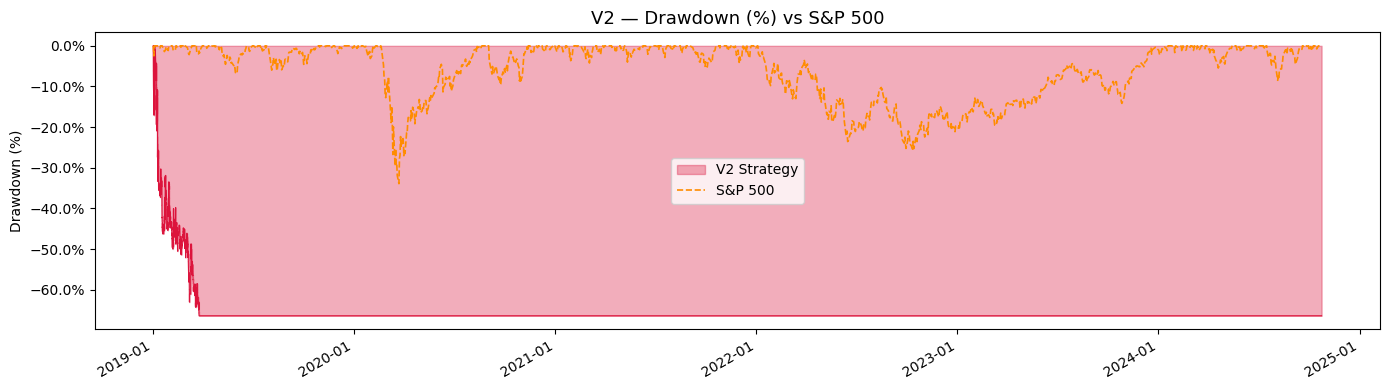

In [2]:
# ── Compute strategy drawdown ─────────────────────────────────────────────────
eq_vals = ec["equity"].values
eq_peak = np.maximum.accumulate(eq_vals)
dd_pct  = (eq_vals - eq_peak) / eq_peak * 100

# ── Compute S&P 500 drawdown ──────────────────────────────────────────────────
sp_vals = sp_norm.values
sp_peak = np.maximum.accumulate(sp_vals)
sp_dd   = (sp_vals - sp_peak) / sp_peak * 100

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(ec["time"], dd_pct, 0, alpha=0.35, color="crimson",
                label=f"{VERSION} Strategy")
ax.plot(ec["time"], dd_pct, color="crimson", lw=0.8)
ax.plot(sp_norm.index, sp_dd, color="darkorange", lw=1.2,
        linestyle="--", label="S&P 500")
ax.set_title(f"{VERSION} — Drawdown (%) vs S&P 500", fontsize=13)
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.1f}%"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [3]:

from IPython.display import display

trades = pd.read_csv("trades.csv", parse_dates=["entry_time", "exit_time"])

# ── Strategy metrics ──────────────────────────────────────────────────────────
daily_ec  = ec.set_index("time")["equity"].resample("D").last().dropna()
daily_ret = daily_ec.pct_change().dropna()
TRADING_DAYS = 252

n_days        = (ec["time"].iloc[-1] - ec["time"].iloc[0]).days
final_eq      = ec["equity"].iloc[-1]
total_ret_pct = (final_eq / START_EQ - 1) * 100
ann_ret_pct   = ((final_eq / START_EQ) ** (365 / max(n_days, 1)) - 1) * 100
sharpe        = (daily_ret.mean() / daily_ret.std() * TRADING_DAYS**0.5
                 if daily_ret.std() > 0 else 0.0)
max_dd_pct    = dd_pct.min()
win_rate      = trades["label_win"].mean() * 100
n_trades      = len(trades)
exit_counts   = trades["exit_reason"].value_counts().to_dict()

# ── S&P 500 metrics ───────────────────────────────────────────────────────────
sp_ret_daily = sp_raw.pct_change().dropna()
sp_n_days    = (sp_raw.index[-1] - sp_raw.index[0]).days
sp_total_ret = (sp_raw.iloc[-1] / sp_raw.iloc[0] - 1) * 100
sp_ann_ret   = ((sp_raw.iloc[-1] / sp_raw.iloc[0]) ** (365 / max(sp_n_days, 1)) - 1) * 100
sp_sharpe    = (sp_ret_daily.mean() / sp_ret_daily.std() * TRADING_DAYS**0.5
                if sp_ret_daily.std() > 0 else 0.0)
sp_max_dd    = sp_dd.min()

# ── Comparison table ──────────────────────────────────────────────────────────
rows = {
    "Total Return (%)":       [f"{total_ret_pct:+.2f}%", f"{sp_total_ret:+.2f}%"],
    "Annualised Return (%)":  [f"{ann_ret_pct:+.2f}%",   f"{sp_ann_ret:+.2f}%"],
    "Sharpe Ratio (ann.)":    [f"{sharpe:.3f}",           f"{sp_sharpe:.3f}"],
    "Max Drawdown (%)":       [f"{max_dd_pct:.2f}%",      f"{sp_max_dd:.2f}%"],
    "Win Rate (%)":           [f"{win_rate:.1f}%",         "N/A"],
    "Trades Taken":           [f"{n_trades:,}",            "N/A"],
    "Exit: Take Profit":      [f"{exit_counts.get('take_profit', 0):,}", "N/A"],
    "Exit: Stop Loss":        [f"{exit_counts.get('stop', 0):,}",        "N/A"],
    "Exit: Opposite Signal":  [f"{exit_counts.get('opposite_signal', 0):,}", "N/A"],
    "Exit: End of Data":      [f"{exit_counts.get('end_of_data', 0):,}", "N/A"],
}
metrics_df = pd.DataFrame(rows, index=[VERSION, "S&P 500"]).T
display(
    metrics_df.style
    .set_caption(f"{VERSION} — Key Performance Metrics vs S&P 500")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-size", "14px"),
                                  ("font-weight", "bold"),
                                  ("text-align", "left")]}])
)


,V2,S&P 500
Total Return (%),-60.35%,+133.11%
Annualised Return (%),-14.71%,+15.69%
Sharpe Ratio (ann.),-0.448,0.821
Max Drawdown (%),-66.43%,-33.92%
Win Rate (%),1.0%,N/A
Trades Taken,"53,259",N/A
Exit: Take Profit,"2,830",N/A
Exit: Stop Loss,"5,508",N/A
Exit: Opposite Signal,"44,921",N/A
Exit: End of Data,0,N/A


In [4]:

mc = json.load(open("monte_carlo.json"))
dd = mc["max_drawdown"]

mc_rows = {
    "Bootstrap Method":         [mc["bootstrap_method"]],
    "Simulations":              [f"{mc['n_sims']:,}"],
    "Observed Trades":          [f"{mc['n_trades']:,}"],
    "Seed":                     [mc["seed"]],
    "Max Drawdown p50 ($)":     [f"${dd['p50']:,.2f}"],
    "Max Drawdown p90 ($)":     [f"${dd['p90']:,.2f}"],
    "Max Drawdown p95 ($)":     [f"${dd['p95']:,.2f}"],
    "Max Drawdown p99 ($)":     [f"${dd['p99']:,.2f}"],
    "Max Drawdown Worst ($)":   [f"${dd['worst']:,.2f}"],
    "VaR 5th pct (per trade)":  [f"${mc['var_trade_pnl']:,.2f}"],
    "CVaR 5th pct (per trade)": [f"${mc['cvar_trade_pnl']:,.4f}"],
    "Risk of Ruin Prob":        [f"{mc['risk_of_ruin_prob']*100:.1f}%"],
    "Ruin Definition":          [mc["ruin_definition"]],
}
mc_df = pd.DataFrame(mc_rows, index=["Value"]).T
display(
    mc_df.style
    .set_caption(
        f"{VERSION} — Monte Carlo Risk Metrics "
        f"(IID Bootstrap, {mc['n_sims']:,} sims)"
    )
    .set_table_styles([{"selector": "caption",
                        "props": [("font-size", "14px"),
                                  ("font-weight", "bold"),
                                  ("text-align", "left")]}])
)


,Value
Bootstrap Method,iid
Simulations,"10,000"
Observed Trades,"53,259"
Seed,42
Max Drawdown p50 ($),"$1,816.00"
Max Drawdown p90 ($),"$2,861.60"
Max Drawdown p95 ($),"$3,184.02"
Max Drawdown p99 ($),"$3,714.52"
Max Drawdown Worst ($),"$5,568.50"
VaR 5th pct (per trade),$0.00
